# Tarea M22-CD – Lucy Bravo
## Análisis de clasificación con Máquinas de Soporte Vectorial (SVM)
### Predicción de rotación de personal (*employee attrition*)

**Base de datos:** `recursos_humanos.csv` (14,999 empleados)

**Objetivo del análisis:** construir un modelo predictivo que identifique qué empleados tienen
probabilidad de abandonar la empresa (`left = 1`), probando los **cuatro kernels** de SVM
vistos en la lección: **lineal, polinomial, RBF y sigmoide**. Para cada kernel se elabora el
**mapa de calor de la matriz de confusión** y el **reporte de clasificación detallado**, se
interpretan los indicadores y finalmente se elige el modelo más adecuado para pronosticar
el caso de un empleado nuevo.

**Variables:**

| Variable | Descripción |
|---|---|
| `satisfaction_level` | Nivel de satisfacción (0 a 1) |
| `last_evaluation` | Puntaje de la última evaluación (0 a 1) |
| `number_project` | Número de proyectos asignados |
| `average_montly_hours` | Promedio de horas trabajadas al mes |
| `time_spend_company` | Antigüedad en la compañía (años) |
| `Work_accident` | Accidente laboral (1 = Sí, 0 = No) |
| `promotion_last_5years` | Promoción en los últimos 5 años (1 = Sí, 0 = No) |
| `sales` | Departamento donde trabaja (categórica) |
| `salary` | Categoría del salario: low / medium / high (categórica) |
| `left` | **Variable objetivo:** dejó la empresa (1 = Sí, 0 = No) |


---
## 1. Importación de librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

# Estilo de las gráficas
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


---
## 2. Carga y exploración de la base de datos

In [2]:
# Carga de la base de datos
df = pd.read_csv('recursos_humanos.csv')

print('Dimensiones de la base:', df.shape)
df.head(10)

Dimensiones de la base: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [3]:
# Estructura y tipos de dato
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [4]:
# Valores faltantes
print('Valores nulos por variable:')
print(df.isnull().sum())
print('\nTotal de valores nulos:', df.isnull().sum().sum())
print('Registros duplicados:', df.duplicated().sum())

Valores nulos por variable:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

Total de valores nulos: 0
Registros duplicados: 3008


**Comentario:** la base no tiene valores faltantes, por lo que no se requiere imputación.
Existen 3,008 registros duplicados, pero en esta base corresponden a empleados distintos que
coinciden en todos sus indicadores (perfiles repetidos con variables discretizadas), por lo que
**se conservan los 14,999 registros** para no perder información.

In [5]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,14999.0,0.613,0.249,0.09,0.44,0.64,0.82,1.0
last_evaluation,14999.0,0.716,0.171,0.36,0.56,0.72,0.87,1.0
number_project,14999.0,3.803,1.233,2.00,3.00,4.00,5.00,7.0
average_montly_hours,14999.0,201.050,49.943,96.00,156.00,200.00,245.00,310.0
time_spend_company,14999.0,3.498,1.460,2.00,3.00,3.00,4.00,10.0
Work_accident,14999.0,0.145,0.352,0.00,0.00,0.00,0.00,1.0
left,14999.0,0.238,0.426,0.00,0.00,0.00,0.00,1.0
promotion_last_5years,14999.0,0.021,0.144,0.00,0.00,0.00,0.00,1.0


Distribución de la variable objetivo (left):
  Se queda (0): 11,428 empleados  (76.19 %)
  Se va    (1):  3,571 empleados  (23.81 %)


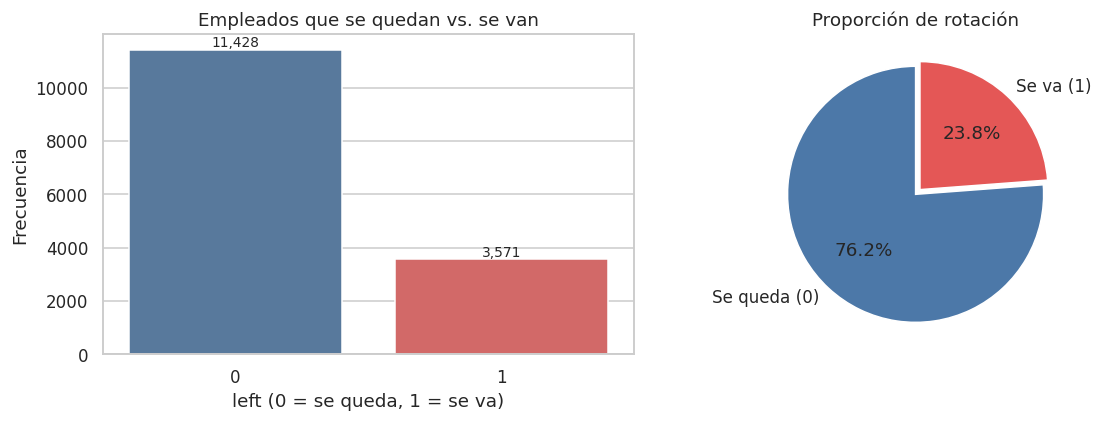

In [6]:
# Distribución de la variable objetivo
conteo = df['left'].value_counts().sort_index()
porcent = df['left'].value_counts(normalize=True).sort_index() * 100

print('Distribución de la variable objetivo (left):')
for k in conteo.index:
    etiqueta = 'Se queda (0)' if k == 0 else 'Se va    (1)'
    print(f'  {etiqueta}: {conteo[k]:>6,} empleados  ({porcent[k]:.2f} %)')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='left', data=df, hue='left', palette=['#4C78A8', '#E45756'],
              legend=False, ax=ax[0])
ax[0].set_title('Empleados que se quedan vs. se van')
ax[0].set_xlabel('left (0 = se queda, 1 = se va)'); ax[0].set_ylabel('Frecuencia')
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                   ha='center', va='bottom', fontsize=9)

ax[1].pie(conteo, labels=['Se queda (0)', 'Se va (1)'], autopct='%1.1f%%',
          colors=['#4C78A8', '#E45756'], startangle=90, explode=(0, 0.05))
ax[1].set_title('Proporción de rotación')
plt.tight_layout(); plt.show()

**Interpretación:** la base está **desbalanceada**: sólo el **23.8 %** de los empleados
abandonó la empresa (3,571) frente al **76.2 %** que permaneció (11,428). Esto es importante
porque un modelo que dijera *"nadie se va"* alcanzaría un 76 % de exactitud sin aprender nada.
Por eso **no basta la exactitud (*accuracy*)**: hay que revisar el *recall* y el *f1-score* de
la clase minoritaria `left = 1`, que es justamente la que interesa a Recursos Humanos.

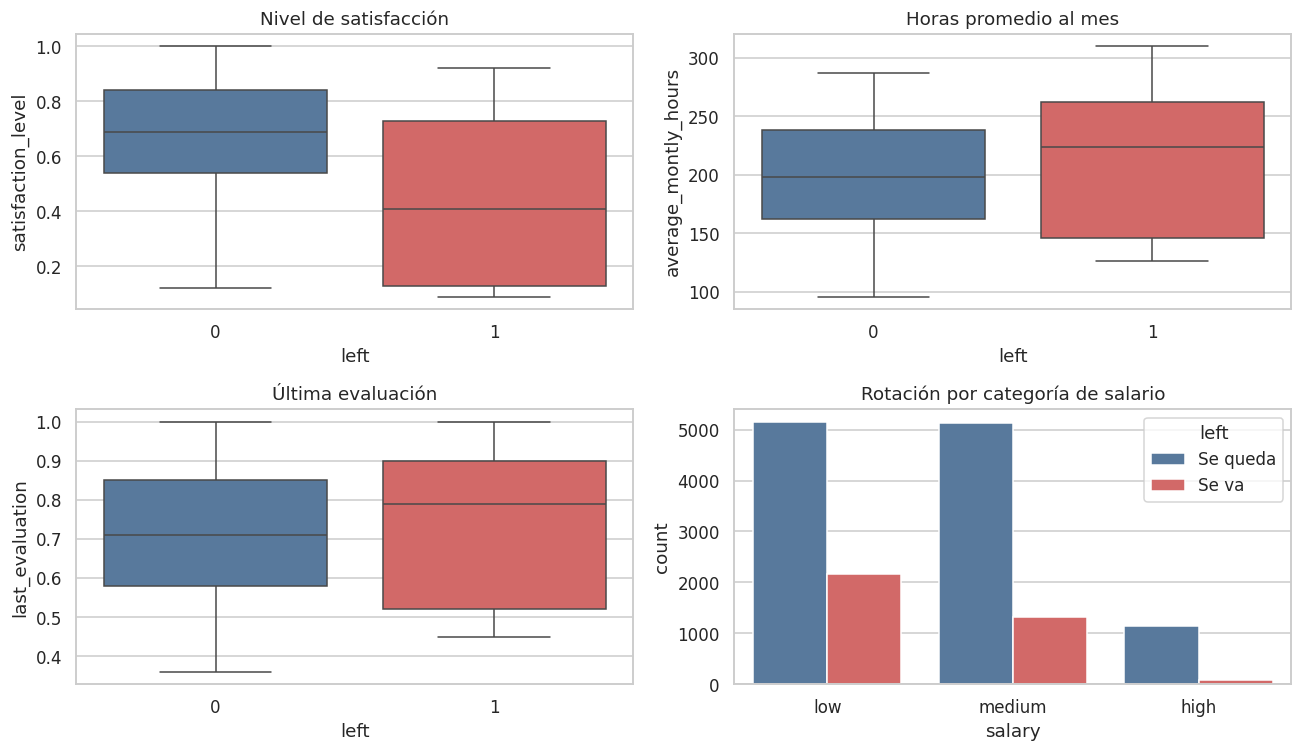

Promedios por grupo:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company
left,,,,,
0,0.667,0.715,3.787,199.060,3.380
1,0.440,0.718,3.856,207.419,3.877


In [7]:
# Comportamiento de las variables clave frente a la rotación
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
sns.boxplot(x='left', y='satisfaction_level', data=df, hue='left',
            palette=['#4C78A8', '#E45756'], legend=False, ax=ax[0, 0])
ax[0, 0].set_title('Nivel de satisfacción')
sns.boxplot(x='left', y='average_montly_hours', data=df, hue='left',
            palette=['#4C78A8', '#E45756'], legend=False, ax=ax[0, 1])
ax[0, 1].set_title('Horas promedio al mes')
sns.boxplot(x='left', y='last_evaluation', data=df, hue='left',
            palette=['#4C78A8', '#E45756'], legend=False, ax=ax[1, 0])
ax[1, 0].set_title('Última evaluación')
sns.countplot(x='salary', hue='left', data=df, order=['low', 'medium', 'high'],
              palette=['#4C78A8', '#E45756'], ax=ax[1, 1])
ax[1, 1].set_title('Rotación por categoría de salario')
ax[1, 1].legend(title='left', labels=['Se queda', 'Se va'])
plt.tight_layout(); plt.show()

print('Promedios por grupo:')
df.groupby('left')[['satisfaction_level', 'last_evaluation', 'number_project',
                    'average_montly_hours', 'time_spend_company']].mean().round(3)

**Interpretación:** quienes se van reportan una **satisfacción notablemente menor**
(0.44 vs. 0.67 en promedio) y trabajan **más horas al mes** (207 vs. 199), con evaluaciones prácticamente
idénticas en promedio (0.718 vs. 0.715) pero de distribución **bimodal**: se van tanto los de
evaluación muy alta como los de evaluación muy baja. La rotación se concentra en los salarios
**bajos y medios** (se va el 29.7 % de los de salario bajo, 20.4 % de los medios y sólo 6.6 % de
los altos). Es decir,
la empresa está perdiendo gente con buen desempeño, sobrecargada y mal pagada: hay señal
suficiente para que un modelo de clasificación funcione.

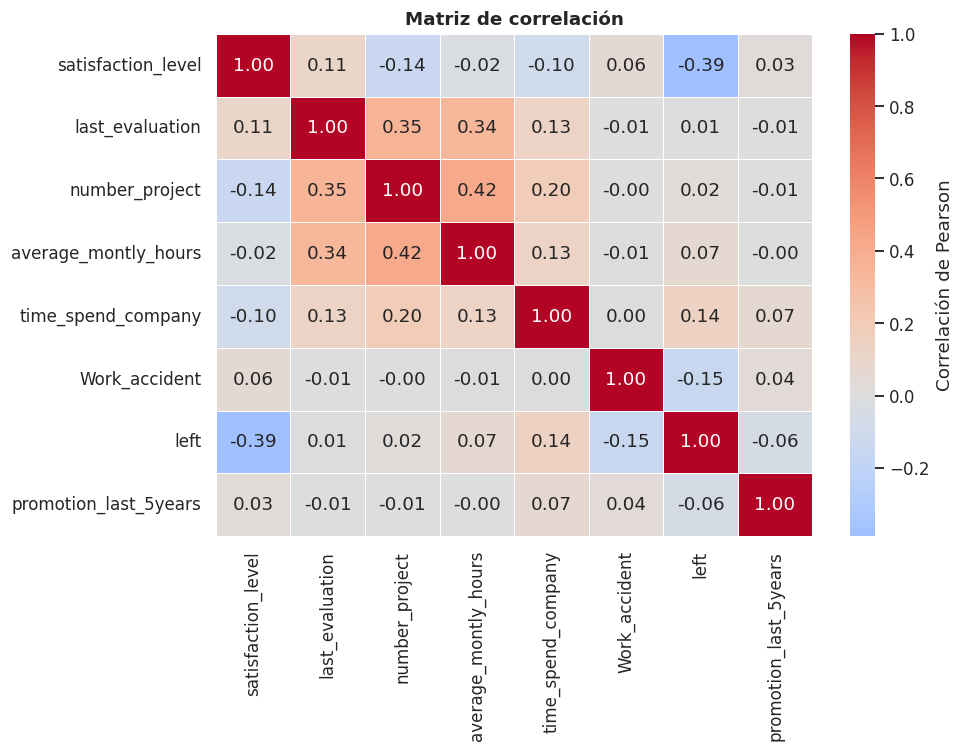

In [8]:
# Matriz de correlación de las variables numéricas
plt.figure(figsize=(9, 7))
num = df.select_dtypes(include=[np.number])
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=.5, cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Matriz de correlación', fontsize=12, weight='bold')
plt.tight_layout(); plt.show()

**Interpretación:** la correlación más fuerte con `left` es la del **nivel de satisfacción
(−0.39)**: a menor satisfacción, mayor probabilidad de irse. Le siguen la antigüedad (+0.14),
el número de proyectos (+0.02, débil de forma lineal) y el accidente laboral (−0.15). Ninguna
correlación lineal es muy alta, lo cual **anticipa que un kernel no lineal (RBF o polinomial)
capturará mejor la relación** que el kernel lineal.

---
## 3. Recodificación de las variables categóricas con `pd.get_dummies`

Las SVM trabajan con distancias en un espacio numérico, por lo que **no admiten texto**. Las dos
variables categóricas de la base son:

* `sales` → 10 departamentos (IT, RandD, accounting, hr, management, marketing, product_mng, sales, support, technical)
* `salary` → 3 categorías (low, medium, high)

Con `pd.get_dummies` cada categoría se convierte en una **columna binaria (0/1)**. Se usa
`drop_first=True` para eliminar una categoría de referencia en cada variable y **evitar
multicolinealidad** (la llamada *trampa de las variables dummy*): las categorías de referencia
son `sales = IT` y `salary = high`, de modo que un empleado de IT con salario alto queda
representado con ceros en todas las dummies.

In [9]:
# Recodificación de las variables categóricas
print('Categorías originales:')
print('  sales :', sorted(df['sales'].unique()))
print('  salary:', sorted(df['salary'].unique()))

df_model = pd.get_dummies(df, columns=['sales', 'salary'], drop_first=True, dtype=int)

print('\nDimensiones antes  :', df.shape)
print('Dimensiones después:', df_model.shape)
print('\nColumnas resultantes:')
print(list(df_model.columns))
df_model.head()

Categorías originales:
  sales : ['IT', 'RandD', 'accounting', 'hr', 'management', 'marketing', 'product_mng', 'sales', 'support', 'technical']
  salary: ['high', 'low', 'medium']

Dimensiones antes  : (14999, 10)
Dimensiones después: (14999, 19)

Columnas resultantes:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'sales_RandD', 'sales_accounting', 'sales_hr', 'sales_management', 'sales_marketing', 'sales_product_mng', 'sales_sales', 'sales_support', 'sales_technical', 'salary_low', 'salary_medium']


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


---
## 4. Definición de variables, división y **escalamiento**

El escalamiento es **indispensable** en SVM: `average_montly_hours` va de 96 a 310 mientras que
`satisfaction_level` va de 0 a 1. Sin estandarizar, la variable de horas dominaría por completo
el cálculo de las distancias y el margen quedaría distorsionado. Se usa `StandardScaler`
(media 0, desviación 1), **ajustado únicamente con los datos de entrenamiento** para no filtrar
información del conjunto de prueba (*data leakage*).

In [10]:
# Variables predictoras (X) y variable objetivo (y)
X = df_model.drop('left', axis=1)
y = df_model['left']

print('X (predictoras):', X.shape)
print('y (objetivo)   :', y.shape)

# División entrenamiento / prueba 70 % - 30 %, estratificada para conservar la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print(f'\nEntrenamiento: {X_train.shape[0]:,} registros')
print(f'Prueba       : {X_test.shape[0]:,} registros')
print(f'\nProporción de "se va" en entrenamiento: {y_train.mean():.4f}')
print(f'Proporción de "se va" en prueba       : {y_test.mean():.4f}')

# Escalamiento
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('\nDatos escalados. Verificación en entrenamiento:')
print(f'  media ≈ {X_train_sc.mean():.6f}   desviación ≈ {X_train_sc.std():.6f}')

X (predictoras): (14999, 18)
y (objetivo)   : (14999,)

Entrenamiento: 10,499 registros
Prueba       : 4,500 registros

Proporción de "se va" en entrenamiento: 0.2381
Proporción de "se va" en prueba       : 0.2380

Datos escalados. Verificación en entrenamiento:
  media ≈ -0.000000   desviación ≈ 1.000000


---
## 5. Modelos SVM con los cuatro kernels

Se define una función que entrena el modelo, dibuja el **mapa de calor de la matriz de
confusión** e imprime el **reporte de clasificación**, de modo que los cuatro kernels se
evalúen exactamente bajo las mismas condiciones.

**Cómo leer la matriz de confusión:**

|  | Predicho: se queda | Predicho: se va |
|---|---|---|
| **Real: se queda** | VN – Verdadero negativo | FP – Falso positivo (falsa alarma) |
| **Real: se va** | FN – Falso negativo (fuga no detectada) | VP – Verdadero positivo |

**Métricas del reporte de clasificación:**

* **Precisión (*precision*)** = VP / (VP + FP) → de los que el modelo señala como fuga, ¿cuántos realmente se van?
* **Sensibilidad (*recall*)** = VP / (VP + FN) → de todos los que realmente se van, ¿cuántos detecta el modelo?
* **F1-score** = media armónica de precisión y recall → equilibrio entre ambas.
* **Exactitud (*accuracy*)** = aciertos totales / total. Poco confiable con clases desbalanceadas.

In [11]:
def evaluar_svm(kernel, X_tr, y_tr, X_te, y_te, **kwargs):
    """Entrena una SVM con el kernel indicado, grafica el mapa de calor de la
    matriz de confusión e imprime el reporte de clasificación detallado."""

    modelo = SVC(kernel=kernel, random_state=42, **kwargs)
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    cm = confusion_matrix(y_te, y_pred)

    # --- Mapa de calor de la matriz de confusión ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, linewidths=1,
                linecolor='white', annot_kws={'size': 13, 'weight': 'bold'},
                xticklabels=['Se queda (0)', 'Se va (1)'],
                yticklabels=['Se queda (0)', 'Se va (1)'], ax=ax[0])
    ax[0].set_title(f'Matriz de confusión — kernel {kernel.upper()}\n(frecuencias)',
                    fontsize=11, weight='bold')
    ax[0].set_xlabel('Predicho'); ax[0].set_ylabel('Real')

    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', cbar=False, linewidths=1,
                linecolor='white', annot_kws={'size': 13, 'weight': 'bold'},
                xticklabels=['Se queda (0)', 'Se va (1)'],
                yticklabels=['Se queda (0)', 'Se va (1)'], ax=ax[1])
    ax[1].set_title(f'Matriz de confusión — kernel {kernel.upper()}\n(% por clase real)',
                    fontsize=11, weight='bold')
    ax[1].set_xlabel('Predicho'); ax[1].set_ylabel('Real')
    plt.tight_layout(); plt.show()

    # --- Reporte de clasificación ---
    print('=' * 68)
    print(f'REPORTE DE CLASIFICACIÓN — KERNEL {kernel.upper()}')
    print('=' * 68)
    print(classification_report(y_te, y_pred, digits=4,
                                target_names=['Se queda (0)', 'Se va (1)']))
    vn, fp, fn, vp = cm.ravel()
    print(f'Verdaderos negativos (VN): {vn:>5,}   |  Falsos positivos (FP): {fp:>5,}')
    print(f'Falsos negativos     (FN): {fn:>5,}   |  Verdaderos positivos (VP): {vp:>5,}')
    print(f'\nVectores de soporte utilizados: {modelo.n_support_.sum():,} '
          f'de {X_tr.shape[0]:,} observaciones de entrenamiento')

    metricas = dict(Kernel=kernel,
                    Exactitud=accuracy_score(y_te, y_pred),
                    Precision=precision_score(y_te, y_pred),
                    Recall=recall_score(y_te, y_pred),
                    F1=f1_score(y_te, y_pred),
                    F1_macro=f1_score(y_te, y_pred, average='macro'),
                    VN=vn, FP=fp, FN=fn, VP=vp)
    return modelo, y_pred, metricas


resultados = []   # aquí se irán guardando las métricas de cada kernel
print('Función de evaluación definida.')

Función de evaluación definida.


### 5.1 Kernel **LINEAL**

Separa las clases con un **hiperplano recto**: `K(xᵢ, xⱼ) = xᵢᵀ · xⱼ`. Es el modelo más
simple y sirve como punto de comparación.

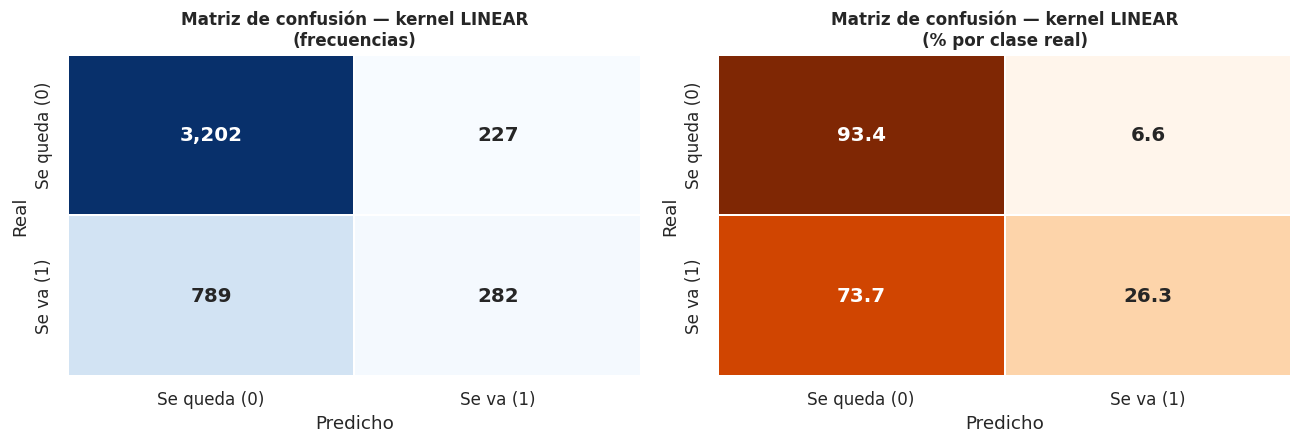

REPORTE DE CLASIFICACIÓN — KERNEL LINEAR
              precision    recall  f1-score   support

Se queda (0)     0.8023    0.9338    0.8631      3429
   Se va (1)     0.5540    0.2633    0.3570      1071

    accuracy                         0.7742      4500
   macro avg     0.6782    0.5986    0.6100      4500
weighted avg     0.7432    0.7742    0.7426      4500

Verdaderos negativos (VN): 3,202   |  Falsos positivos (FP):   227
Falsos negativos     (FN):   789   |  Verdaderos positivos (VP):   282

Vectores de soporte utilizados: 4,879 de 10,499 observaciones de entrenamiento


In [12]:
modelo_lin, pred_lin, met_lin = evaluar_svm('linear', X_train_sc, y_train, X_test_sc, y_test, C=1.0)
resultados.append(met_lin)

#### Interpretación — kernel lineal

* **Exactitud 77.42 %**: parece aceptable, pero es prácticamente igual al 76.2 % que se
  obtendría prediciendo *"nadie se va"*. La métrica engaña por el desbalance.
* **Clase "se va": precisión 0.5540 y recall 0.2633.** El recall es el dato crítico: el modelo
  **sólo detecta 282 de los 1,071 empleados que realmente se fueron (26 %)** y deja pasar
  **789 falsos negativos**. Además, de cada 100 alertas que emite, apenas 55 son correctas.
* **F1 de la clase "se va" = 0.3570**, muy bajo.
* **Conclusión:** las clases **no son linealmente separables**. Un hiperplano recto no puede
  modelar la relación real (por ejemplo, se van tanto los empleados quemados con muchas horas
  como los desatendidos con pocas: dos grupos opuestos que un plano no puede aislar). Este
  modelo sería inservible para Recursos Humanos, porque dejaría escapar a 3 de cada 4 personas
  en riesgo de fuga.

### 5.2 Kernel **POLINOMIAL**

Proyecta los datos a un espacio de mayor dimensión con
`K(xᵢ, xⱼ) = (γ · xᵢᵀ · xⱼ + r)^d`, con grado *d* = 3, permitiendo fronteras curvas.

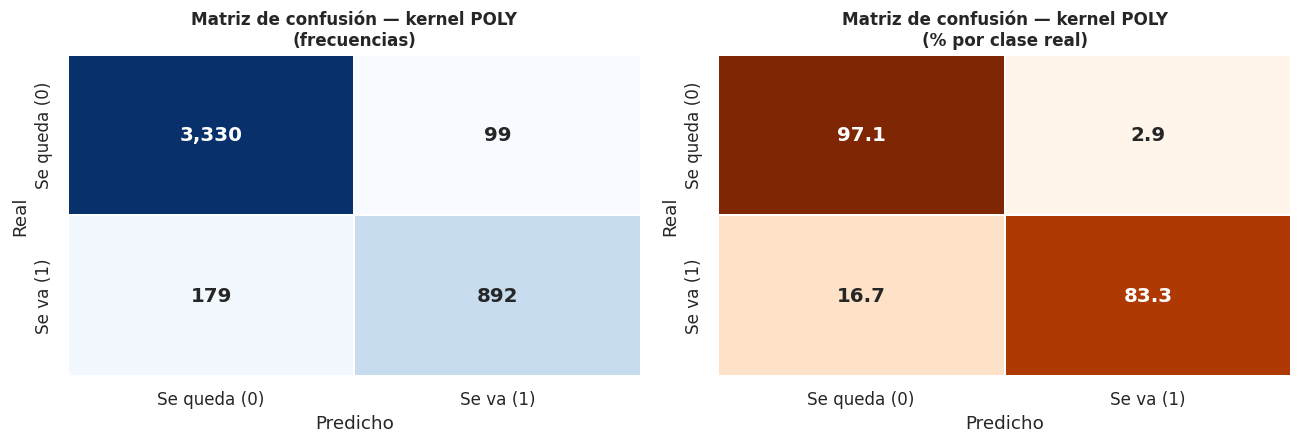

REPORTE DE CLASIFICACIÓN — KERNEL POLY
              precision    recall  f1-score   support

Se queda (0)     0.9490    0.9711    0.9599      3429
   Se va (1)     0.9001    0.8329    0.8652      1071

    accuracy                         0.9382      4500
   macro avg     0.9245    0.9020    0.9126      4500
weighted avg     0.9374    0.9382    0.9374      4500

Verdaderos negativos (VN): 3,330   |  Falsos positivos (FP):    99
Falsos negativos     (FN):   179   |  Verdaderos positivos (VP):   892

Vectores de soporte utilizados: 2,702 de 10,499 observaciones de entrenamiento


In [13]:
modelo_poly, pred_poly, met_poly = evaluar_svm('poly', X_train_sc, y_train, X_test_sc, y_test,
                                                degree=3, gamma='scale', coef0=0.0, C=1.0)
resultados.append(met_poly)

#### Interpretación — kernel polinomial

* **Exactitud 93.82 %**: salto enorme de más de 16 puntos frente al lineal, lo que confirma que
  la frontera entre quedarse e irse es **no lineal**.
* **Clase "se va": precisión 0.9001 y recall 0.8329.** Detecta 892 de 1,071 fugas reales y
  produce sólo 99 falsas alarmas. Cuando avisa que alguien se va, acierta el 90 % de las veces.
* **F1 de la clase "se va" = 0.8652**, muy bueno.
* **Punto débil:** quedan **179 falsos negativos** (16.7 % de las fugas pasa inadvertida), casi
  el doble que el kernel RBF. Es un modelo **conservador**: prefiere no avisar antes que
  equivocarse, lo que en retención de personal es justamente el error más costoso.

### 5.3 Kernel **RBF** (radial o gaussiano)

Kernel gaussiano `K(xᵢ, xⱼ) = exp(−γ · ‖xᵢ − xⱼ‖²)`. Es el kernel por
defecto de `SVC` y el más flexible: construye fronteras locales alrededor de los grupos de
observaciones.

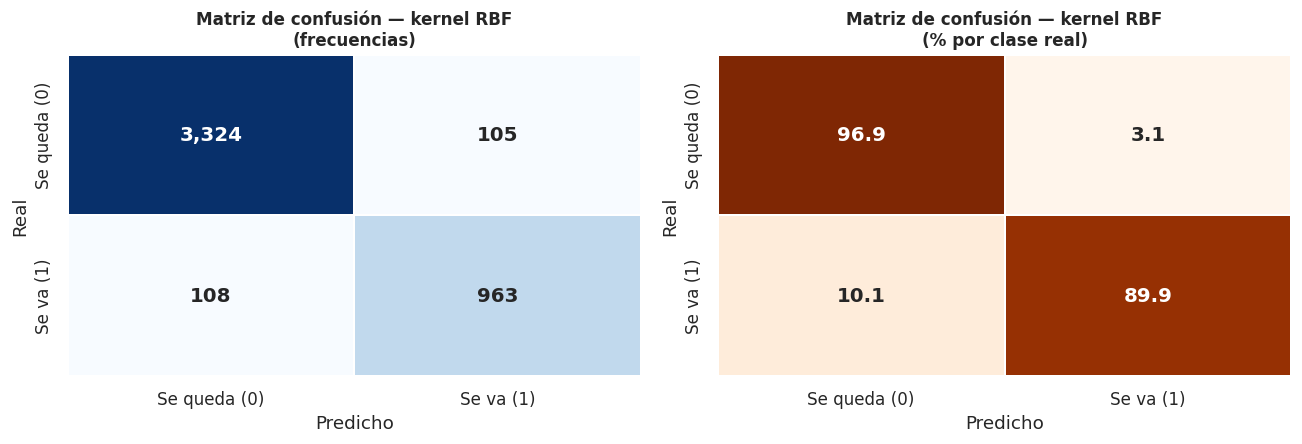

REPORTE DE CLASIFICACIÓN — KERNEL RBF
              precision    recall  f1-score   support

Se queda (0)     0.9685    0.9694    0.9690      3429
   Se va (1)     0.9017    0.8992    0.9004      1071

    accuracy                         0.9527      4500
   macro avg     0.9351    0.9343    0.9347      4500
weighted avg     0.9526    0.9527    0.9526      4500

Verdaderos negativos (VN): 3,324   |  Falsos positivos (FP):   105
Falsos negativos     (FN):   108   |  Verdaderos positivos (VP):   963

Vectores de soporte utilizados: 2,138 de 10,499 observaciones de entrenamiento


In [14]:
modelo_rbf, pred_rbf, met_rbf = evaluar_svm('rbf', X_train_sc, y_train, X_test_sc, y_test,
                                             gamma='scale', C=1.0)
resultados.append(met_rbf)

#### Interpretación — kernel RBF

* **Exactitud 95.27 %**, la más alta de los cuatro kernels.
* **Clase "se va": precisión 0.9017, recall 0.8992, F1 0.9004.** Es el único modelo que supera
  el 0.90 en las tres métricas de la clase de interés, y su equilibrio precisión-recall es casi
  perfecto (no gana en una a costa de la otra).
* **Detecta 963 de las 1,071 fugas reales** y sólo deja pasar **108 falsos negativos**, es decir
  **71 empleados en riesgo más que el kernel polinomial**. Genera 105 falsas alarmas, un costo
  bajo y perfectamente manejable (implican una entrevista de retención innecesaria).
* **F1 macro 0.9347**: buen desempeño en *ambas* clases, no sólo en la mayoritaria.
* Usa **2,138 vectores de soporte**, los menos de los cuatro modelos: describe la frontera con
  menos observaciones críticas, lo que indica una separación más nítida y un modelo más estable.

### 5.4 Kernel **SIGMOIDE**

`K(xᵢ, xⱼ) = tanh(γ · xᵢᵀ · xⱼ + r)`, inspirado en las redes neuronales. Es un
kernel sensible al valor de γ y a la escala de los datos, y **no siempre genera una
matriz definida positiva**, por lo que puede comportarse de forma inestable.

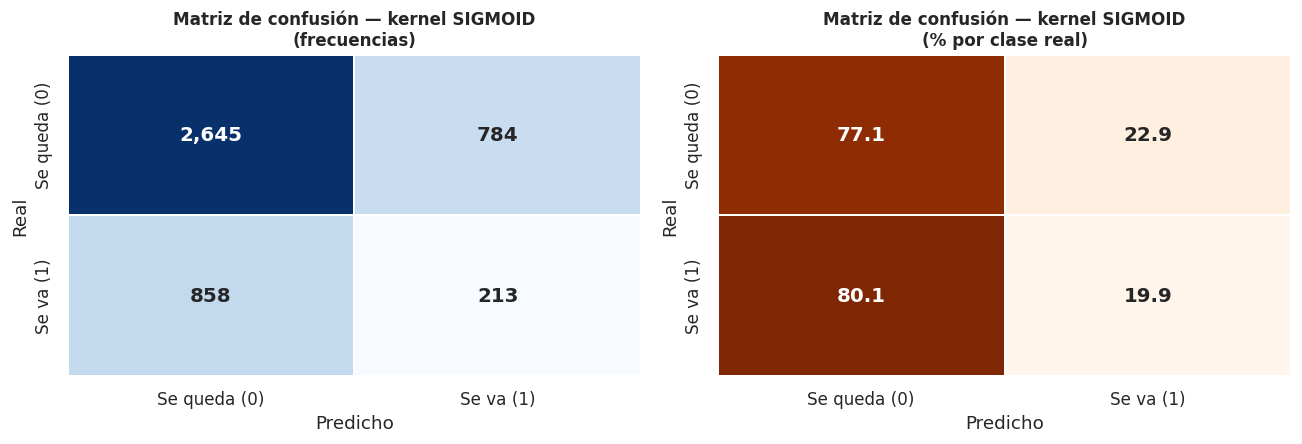

REPORTE DE CLASIFICACIÓN — KERNEL SIGMOID
              precision    recall  f1-score   support

Se queda (0)     0.7551    0.7714    0.7631      3429
   Se va (1)     0.2136    0.1989    0.2060      1071

    accuracy                         0.6351      4500
   macro avg     0.4844    0.4851    0.4846      4500
weighted avg     0.6262    0.6351    0.6305      4500

Verdaderos negativos (VN): 2,645   |  Falsos positivos (FP):   784
Falsos negativos     (FN):   858   |  Verdaderos positivos (VP):   213

Vectores de soporte utilizados: 4,184 de 10,499 observaciones de entrenamiento


In [15]:
modelo_sig, pred_sig, met_sig = evaluar_svm('sigmoid', X_train_sc, y_train, X_test_sc, y_test,
                                            gamma='scale', coef0=0.0, C=1.0)
resultados.append(met_sig)

#### Interpretación — kernel sigmoide

* **Exactitud 63.51 %**: el **peor** de los cuatro; queda **por debajo del 76.2 %** que se
  obtendría con la regla trivial de predecir siempre "se queda". El modelo destruye información
  en lugar de aportarla.
* **Clase "se va": precisión 0.2136 y recall 0.1989.** De cada 5 alertas, sólo 1 es correcta;
  detecta apenas 213 de 1,071 fugas. Además clasifica mal a 784 empleados que sí se quedaban.
* **F1 macro 0.4846**, equivalente a un desempeño cercano al azar.
* **Explicación:** la función tangente hiperbólica satura (se aplana en −1 y +1) y con datos
  estandarizados de 18 dimensiones pierde capacidad de discriminación; la transformación que
  aplica no corresponde a la geometría de estos datos. **Este kernel debe descartarse.**

---
## 6. Comparación de los cuatro modelos y elección del mejor

In [16]:
# Tabla comparativa
tabla = pd.DataFrame(resultados).set_index('Kernel')
tabla.index = [k.upper() for k in tabla.index]

comparativa = tabla[['Exactitud', 'Precision', 'Recall', 'F1', 'F1_macro']].round(4)
comparativa.columns = ['Exactitud', 'Precisión (se va)', 'Recall (se va)',
                       'F1 (se va)', 'F1 macro']
print('COMPARATIVA DE MÉTRICAS — conjunto de prueba (4,500 empleados)')
print('=' * 78)
display(comparativa)

print('\nERRORES COMETIDOS POR CADA MODELO')
print('=' * 78)
errores = tabla[['VN', 'FP', 'FN', 'VP']].copy()
errores['Errores totales'] = errores['FP'] + errores['FN']
display(errores)

COMPARATIVA DE MÉTRICAS — conjunto de prueba (4,500 empleados)


,Exactitud,Precisión (se va),Recall (se va),F1 (se va),F1 macro
LINEAR,0.7742,0.5540,0.2633,0.3570,0.6100
POLY,0.9382,0.9001,0.8329,0.8652,0.9126
RBF,0.9527,0.9017,0.8992,0.9004,0.9347
SIGMOID,0.6351,0.2136,0.1989,0.2060,0.4846



ERRORES COMETIDOS POR CADA MODELO


,VN,FP,FN,VP,Errores totales
LINEAR,3202,227,789,282,1016
POLY,3330,99,179,892,278
RBF,3324,105,108,963,213
SIGMOID,2645,784,858,213,1642


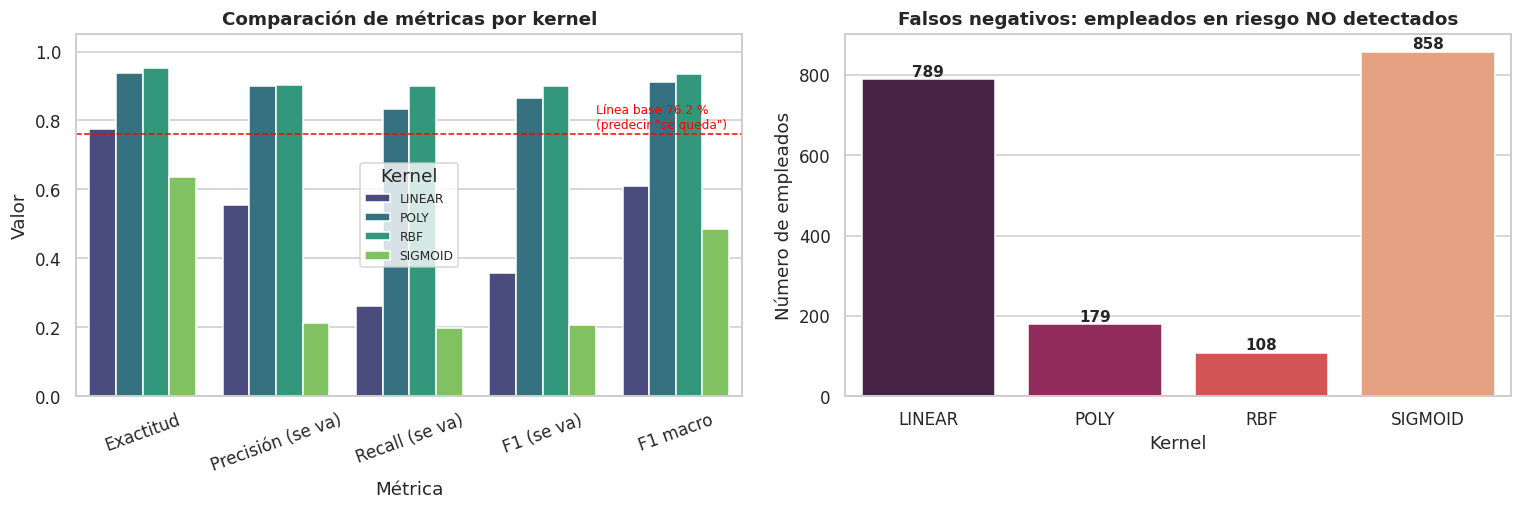

Mejor modelo según F1 macro: kernel RBF  (F1 macro = 0.9347)


In [17]:
# Gráfica comparativa de métricas
met_plot = comparativa.reset_index().melt(id_vars='index', var_name='Métrica', value_name='Valor')
met_plot = met_plot.rename(columns={'index': 'Kernel'})

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
sns.barplot(data=met_plot, x='Métrica', y='Valor', hue='Kernel',
            palette='viridis', ax=ax[0])
ax[0].set_title('Comparación de métricas por kernel', fontsize=12, weight='bold')
ax[0].set_ylim(0, 1.05); ax[0].tick_params(axis='x', rotation=20)
ax[0].axhline(0.762, ls='--', c='red', lw=1)
ax[0].text(3.4, 0.775, 'Línea base 76.2 %\n(predecir "se queda")', color='red', fontsize=8)
ax[0].legend(title='Kernel', fontsize=8)

# Falsos negativos: el error más costoso para Recursos Humanos
sns.barplot(x=tabla.index, y=tabla['FN'], hue=tabla.index, palette='rocket',
            legend=False, ax=ax[1])
ax[1].set_title('Falsos negativos: empleados en riesgo NO detectados',
                fontsize=12, weight='bold')
ax[1].set_ylabel('Número de empleados'); ax[1].set_xlabel('Kernel')
for p in ax[1].patches:
    ax[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                   ha='center', va='bottom', fontsize=10, weight='bold')
plt.tight_layout(); plt.show()

mejor = tabla['F1_macro'].idxmax()
print(f'Mejor modelo según F1 macro: kernel {mejor}  (F1 macro = {tabla["F1_macro"].max():.4f})')

### ¿Cuál resultó ser el modelo predictivo más adecuado?

**El modelo más adecuado es la SVM con kernel RBF (radial).** El razonamiento es el siguiente:

**1. Gana en todas las métricas relevantes.** Exactitud 95.27 %, y en la clase de interés
(`left = 1`) precisión 0.9017, recall 0.8992 y F1 0.9004. Su F1 macro (0.9347) es el más alto,
lo que significa que clasifica bien **ambas** clases y no sólo la mayoritaria.

**2. Minimiza el error más costoso.** En rotación de personal el error grave es el **falso
negativo**: un empleado que se iba y el modelo no detectó, por lo que Recursos Humanos no
intervino y la fuga —con su costo de reclutamiento, capacitación y pérdida de conocimiento— ya
no tiene remedio. RBF deja pasar **108** casos, contra 179 del polinomial, 789 del lineal y 858
del sigmoide. Frente al segundo mejor modelo, **rescata 71 empleados adicionales**.

**3. Mantiene el equilibrio precisión-recall.** Sus dos métricas son prácticamente idénticas
(0.9017 y 0.8992): el modelo no infla las alertas para atrapar más fugas ni se vuelve
conservador para no equivocarse. El polinomial, en contraste, tiene precisión similar (0.9001)
pero un recall claramente inferior (0.8329).

**4. Es el modelo teóricamente correcto para estos datos.** La exploración mostró correlaciones
lineales débiles y grupos de fuga con perfiles opuestos (empleados sobrecargados con muchas
horas y evaluaciones altas, y empleados desatendidos con pocos proyectos y baja satisfacción).
Un hiperplano recto no puede aislar dos regiones separadas; el kernel gaussiano sí, porque
construye fronteras locales alrededor de cada grupo. Esto explica los 17.9 puntos de exactitud
que RBF le gana al lineal.

**5. Es el más parsimonioso.** Usa 2,138 vectores de soporte de 10,499 observaciones de
entrenamiento (20 %), frente a 4,879 del lineal y 4,184 del sigmoide. Necesitar menos vectores
de soporte indica una frontera más limpia y menor riesgo de sobreajuste.

**Orden final de los modelos:** `RBF > Polinomial >> Lineal >> Sigmoide`. El **sigmoide se
descarta por completo**: con 63.51 % de exactitud rinde **peor que la regla trivial** de suponer
que nadie se va (76.2 %), y su F1 macro de 0.4846 lo coloca al nivel del azar.

---
## 7. Pronóstico para un empleado nuevo

Una vez elegido el kernel RBF, se usa para pronosticar casos individuales. La función siguiente
recibe los indicadores del empleado **en su formato original** (incluidos el departamento y la
categoría de salario como texto), se encarga de aplicar internamente la **misma recodificación
con dummies** y el **mismo escalamiento** del entrenamiento, y devuelve el pronóstico.

> **Nota importante:** cualquier empleado nuevo debe pasar exactamente por las mismas
> transformaciones que los datos de entrenamiento —mismas columnas, mismo orden, mismo
> escalador—, de lo contrario la predicción no sería válida.

In [18]:
# Modelo final con estimación de probabilidad
modelo_final = SVC(kernel='rbf', gamma='scale', C=1.0, probability=True, random_state=42)
modelo_final.fit(X_train_sc, y_train)
print('Modelo final (kernel RBF) entrenado.\n')

COLUMNAS = X.columns  # orden exacto de las 18 columnas del modelo

def predecir_empleado(satisfaction_level, last_evaluation, number_project,
                      average_montly_hours, time_spend_company, Work_accident,
                      promotion_last_5years, sales, salary, verbose=True):
    """Pronostica si un empleado dejará la empresa usando la SVM con kernel RBF."""

    # 1) Fila con las variables numéricas y todas las dummies en cero
    fila = pd.DataFrame(0, index=[0], columns=COLUMNAS)
    fila['satisfaction_level']    = satisfaction_level
    fila['last_evaluation']       = last_evaluation
    fila['number_project']        = number_project
    fila['average_montly_hours']  = average_montly_hours
    fila['time_spend_company']    = time_spend_company
    fila['Work_accident']         = Work_accident
    fila['promotion_last_5years'] = promotion_last_5years

    # 2) Activar la dummy correspondiente (IT y high son las categorías de referencia)
    if f'sales_{sales}' in COLUMNAS:
        fila[f'sales_{sales}'] = 1
    elif sales != 'IT':
        raise ValueError(f'Departamento no válido: {sales}')
    if f'salary_{salary}' in COLUMNAS:
        fila[f'salary_{salary}'] = 1
    elif salary != 'high':
        raise ValueError(f'Categoría de salario no válida: {salary}')

    # 3) Escalar con el mismo scaler y predecir
    fila_sc = scaler.transform(fila)
    pred = int(modelo_final.predict(fila_sc)[0])
    prob = modelo_final.predict_proba(fila_sc)[0]

    if verbose:
        print('-' * 62)
        print(f'Satisfacción: {satisfaction_level} | Evaluación: {last_evaluation} | '
              f'Proyectos: {number_project}')
        print(f'Horas/mes: {average_montly_hours} | Antigüedad: {time_spend_company} años | '
              f'Accidente: {Work_accident} | Promoción 5a: {promotion_last_5years}')
        print(f'Departamento: {sales} | Salario: {salary}')
        print(f'>> PRONÓSTICO: left = {pred}  →  '
              f'{"SE VA de la empresa (riesgo de fuga)" if pred == 1 else "SE QUEDA en la empresa"}')
        print(f'   Probabilidad estimada de quedarse: {prob[0]*100:5.2f} %')
        print(f'   Probabilidad estimada de irse    : {prob[1]*100:5.2f} %')
    return pred, prob

Modelo final (kernel RBF) entrenado.



### Caso solicitado

Los indicadores del empleado a pronosticar se capturan a continuación. **Para evaluar otro
empleado basta con modificar los valores de esta celda y ejecutarla de nuevo.**

In [19]:
# ---- INDICADORES DEL EMPLEADO A PRONOSTICAR ----
pred, prob = predecir_empleado(
    satisfaction_level    = 0.20,    # nivel de satisfacción (0 a 1)
    last_evaluation       = 0.85,    # puntaje de la última evaluación (0 a 1)
    number_project        = 6,       # número de proyectos
    average_montly_hours  = 270,     # horas promedio al mes
    time_spend_company    = 4,       # años en la compañía
    Work_accident         = 0,       # 1 = Sí, 0 = No
    promotion_last_5years = 0,       # 1 = Sí, 0 = No
    sales                 = 'sales', # departamento
    salary                = 'low'    # low / medium / high
)

--------------------------------------------------------------
Satisfacción: 0.2 | Evaluación: 0.85 | Proyectos: 6
Horas/mes: 270 | Antigüedad: 4 años | Accidente: 0 | Promoción 5a: 0
Departamento: sales | Salario: low
>> PRONÓSTICO: left = 1  →  SE VA de la empresa (riesgo de fuga)
   Probabilidad estimada de quedarse:  5.63 %
   Probabilidad estimada de irse    : 94.37 %


**Interpretación del caso:** el modelo pronostica **`left = 1`, es decir que este empleado
SÍ dejaría la empresa**, con una probabilidad estimada muy alta. El perfil reúne todos los
factores de riesgo que la exploración identificó: satisfacción muy baja (0.20 frente al promedio
de 0.61), **sobrecarga de trabajo** (270 horas al mes y 6 proyectos, muy por encima de las 201
horas promedio), buen desempeño en su última evaluación (0.85) y **salario bajo sin promoción en
5 años**. Es el caso clásico del empleado valioso y quemado: Recursos Humanos debería
intervenir de inmediato con una revisión de carga de trabajo y de compensación.

### Pronóstico de perfiles adicionales (comparación)

Para verificar que el modelo discrimina de forma coherente, se pronostican tres perfiles
contrastantes.

In [20]:
perfiles = {
 'A) Empleado valioso y sobrecargado': dict(satisfaction_level=0.20, last_evaluation=0.85,
        number_project=6, average_montly_hours=270, time_spend_company=4,
        Work_accident=0, promotion_last_5years=0, sales='sales', salary='low'),
 'B) Empleado satisfecho y estable':   dict(satisfaction_level=0.85, last_evaluation=0.80,
        number_project=4, average_montly_hours=190, time_spend_company=3,
        Work_accident=1, promotion_last_5years=1, sales='technical', salary='high'),
 'C) Empleado desatendido':            dict(satisfaction_level=0.40, last_evaluation=0.50,
        number_project=2, average_montly_hours=140, time_spend_company=3,
        Work_accident=0, promotion_last_5years=0, sales='support', salary='low'),
 'D) Empleado promedio':               dict(satisfaction_level=0.62, last_evaluation=0.72,
        number_project=4, average_montly_hours=200, time_spend_company=3,
        Work_accident=0, promotion_last_5years=0, sales='IT', salary='medium'),
}

filas = []
for nombre, datos in perfiles.items():
    print(f'\n### {nombre}')
    p, pr = predecir_empleado(**datos)
    filas.append({'Perfil': nombre,
                  'Pronóstico': 'SE VA' if p == 1 else 'SE QUEDA',
                  'Prob. de irse (%)': round(pr[1] * 100, 2)})

print('\n\nRESUMEN DE PRONÓSTICOS')
print('=' * 62)
display(pd.DataFrame(filas).set_index('Perfil'))


### A) Empleado valioso y sobrecargado
--------------------------------------------------------------
Satisfacción: 0.2 | Evaluación: 0.85 | Proyectos: 6
Horas/mes: 270 | Antigüedad: 4 años | Accidente: 0 | Promoción 5a: 0
Departamento: sales | Salario: low
>> PRONÓSTICO: left = 1  →  SE VA de la empresa (riesgo de fuga)
   Probabilidad estimada de quedarse:  5.63 %
   Probabilidad estimada de irse    : 94.37 %

### B) Empleado satisfecho y estable
--------------------------------------------------------------
Satisfacción: 0.85 | Evaluación: 0.8 | Proyectos: 4
Horas/mes: 190 | Antigüedad: 3 años | Accidente: 1 | Promoción 5a: 1
Departamento: technical | Salario: high
>> PRONÓSTICO: left = 0  →  SE QUEDA en la empresa
   Probabilidad estimada de quedarse: 96.39 %
   Probabilidad estimada de irse    :  3.61 %

### C) Empleado desatendido
--------------------------------------------------------------
Satisfacción: 0.4 | Evaluación: 0.5 | Proyectos: 2
Horas/mes: 140 | Antigüedad: 3 años 

,Pronóstico,Prob. de irse (%)
Perfil,,
A) Empleado valioso y sobrecargado,SE VA,94.37
B) Empleado satisfecho y estable,SE QUEDA,3.61
C) Empleado desatendido,SE VA,94.18
D) Empleado promedio,SE QUEDA,0.13


**Interpretación:** el modelo se comporta de forma lógica y sensible al perfil. Marca como
**fuga** al empleado sobrecargado y mal pagado (A) y al desatendido con pocos proyectos y baja
satisfacción (C) —los dos patrones de riesgo opuestos que sólo un kernel no lineal puede captar
al mismo tiempo—, mientras que clasifica como **permanencia** al empleado satisfecho, con
salario alto, promovido recientemente (B) y al empleado de indicadores promedio (D).

---
## 8. Conclusiones

1. **Preparación de los datos.** La base de 14,999 empleados no tenía valores faltantes. Las dos
   variables categóricas (`sales` con 10 departamentos y `salary` con 3 niveles) se recodificaron
   con `pd.get_dummies(..., drop_first=True)`, pasando de 10 a 18 variables predictoras. El
   escalamiento con `StandardScaler` fue indispensable, ya que las SVM se basan en distancias.

2. **La elección del kernel lo cambia todo.** Con los mismos datos y los mismos parámetros
   (`C = 1`, `gamma = 'scale'`), la exactitud fue de 63.51 % (sigmoide) a 95.27 % (RBF): casi
   32 puntos de diferencia. El kernel no es un detalle técnico, es la decisión central del modelo.

3. **El mejor modelo es el kernel RBF**, con exactitud 95.27 %, F1 de 0.9004 en la clase "se va"
   y sólo 108 fugas no detectadas de 1,071. El polinomial es una alternativa razonable
   (93.82 %) pero deja pasar 66 % más falsos negativos. El lineal es insuficiente porque las
   clases no son linealmente separables, y el sigmoide debe descartarse por rendir peor que la
   línea base.

4. **No hay que confiar sólo en la exactitud.** Con un 76.2 % de empleados que se quedan, un
   modelo trivial alcanzaría ese valor sin aprender nada. La evaluación tuvo que apoyarse en el
   *recall* y el *F1-score* de la clase minoritaria y en el conteo explícito de falsos negativos.

5. **Valor para Recursos Humanos.** El modelo final permite calcular la probabilidad de fuga de
   cada empleado y priorizar acciones de retención. Los factores de riesgo detectados son
   consistentes y accionables: **baja satisfacción, sobrecarga de horas y proyectos, salario bajo
   y ausencia de promociones**. Detectar 9 de cada 10 fugas antes de que ocurran permite
   intervenir a tiempo, en lugar de reaccionar cuando la renuncia ya está sobre el escritorio.

---
*Tarea M22-CD – Lucy Bravo · Máquinas de Soporte Vectorial · Ciencia de Datos*